# Model Evaluation and Interpretation

This notebook covers:
1. Model evaluation on test data
2. Feature importance analysis
3. SHAP explanations
4. Residual analysis

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance
import joblib
import json

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

In [10]:
# Load data and model
df = pd.read_csv('../data/processed/ames_processed.csv')
X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = joblib.load('../models/best_model.pkl')
print('Model loaded successfully')

Model loaded successfully


## 1. Model Performance

In [11]:
# Make predictions
y_pred = model.predict(X_test)

# Calculate metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# MAPE
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print('Model Performance Metrics:')
print('=' * 40)
print(f'RMSE: ${rmse:,.2f}')
print(f'MAE: ${mae:,.2f}')
print(f'R² Score: {r2:.4f}')
print(f'MAPE: {mape:.2f}%')

# Load saved metrics
with open('../models/model_metrics.json', 'r') as f:
    saved_metrics = json.load(f)
print(f'\nModel: {saved_metrics["model_name"]}')
print(f'Features: {saved_metrics["n_features"]}')

Model Performance Metrics:
RMSE: $21,443.97
MAE: $12,978.22
R² Score: 0.9426
MAPE: 7.05%

Model: CatBoost
Features: 50


## 2. Actual vs Predicted Plot

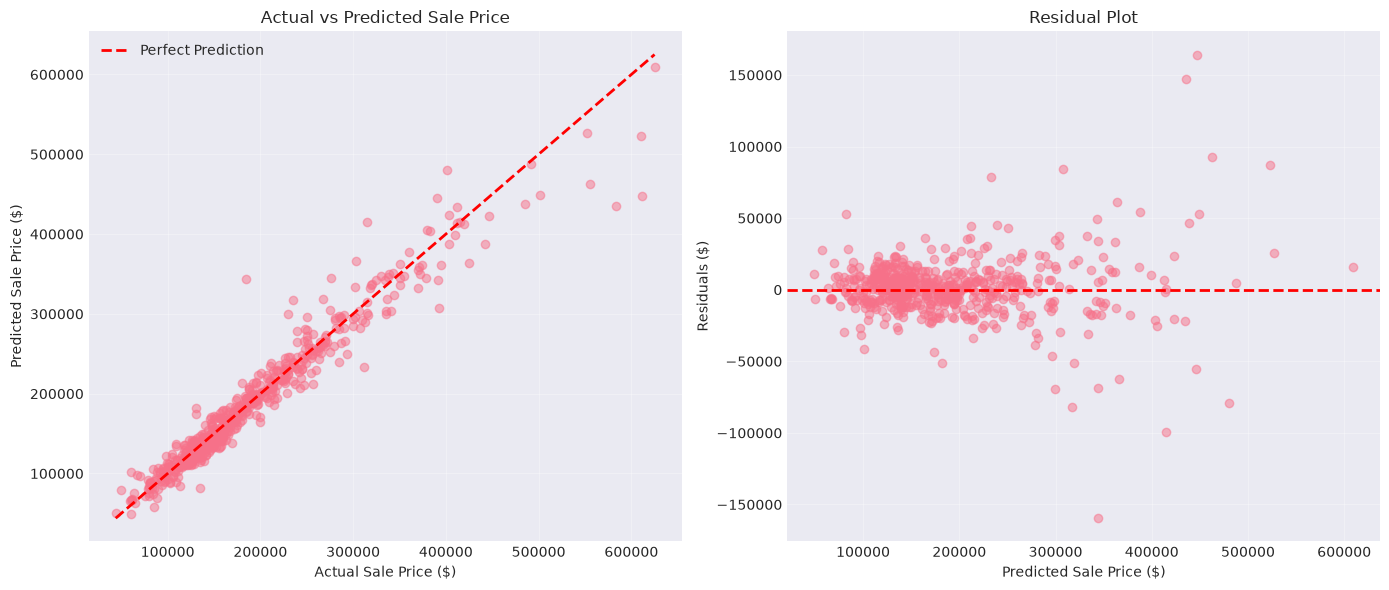

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter plot
axes[0].scatter(y_test, y_pred, alpha=0.5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Sale Price ($)')
axes[0].set_ylabel('Predicted Sale Price ($)')
axes[0].set_title('Actual vs Predicted Sale Price')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Residuals
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.5)
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Sale Price ($)')
axes[1].set_ylabel('Residuals ($)')
axes[1].set_title('Residual Plot')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/residual_plots.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. Feature Importance

In [13]:
from sklearn.inspection import permutation_importance

# Try to get feature importance
try:
    # For tree-based models
    if hasattr(model, 'feature_importances_'):
        importance = model.feature_importances_
        feature_names = X.columns
        importance_df = pd.DataFrame({
            'Feature': feature_names,
            'Importance': importance
        }).sort_values('Importance', ascending=False)
        
        print('Feature Importance from model:')
        print(importance_df.head(20))
    else:
        # Use permutation importance
        print('Calculating permutation importance...')
        result = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)
        importance = result.importances_mean
        feature_names = X.columns
        importance_df = pd.DataFrame({
            'Feature': feature_names,
            'Importance': importance
        }).sort_values('Importance', ascending=False)
        
        print(importance_df.head(20))
except Exception as e:
    print(f'Could not calculate feature importance: {e}')

# Save feature importance
importance_df.to_csv('../models/feature_importance.csv', index=False)
print('\nFeature importance saved to models/feature_importance.csv')

Feature Importance from model:
                          Feature  Importance
37                     Total_Area   19.864799
5                    Overall Qual   14.635104
46                  Quality_Score    5.637587
39                Total_Bathrooms    4.594531
49  Neighborhood_Price_Level_Rank    3.774442
21                    Gr Liv Area    3.639070
16                   BsmtFin SF 1    3.211187
23                   Kitchen Qual    3.022748
19                     1st Flr SF    2.968268
48       Neighborhood_Price_Level    2.870562
14                      Bsmt Qual    2.832153
33                            Age    2.403695
7                      Year Built    2.267192
30                    Garage Cars    2.090718
3                        Lot Area    1.625199
44                  Has_Fireplace    1.621054
35                       Total_SF    1.454197
38                 Lot_Area_Acres    1.428785
8                  Year Remod/Add    1.296606
20                     2nd Flr SF    1.224735

Fe

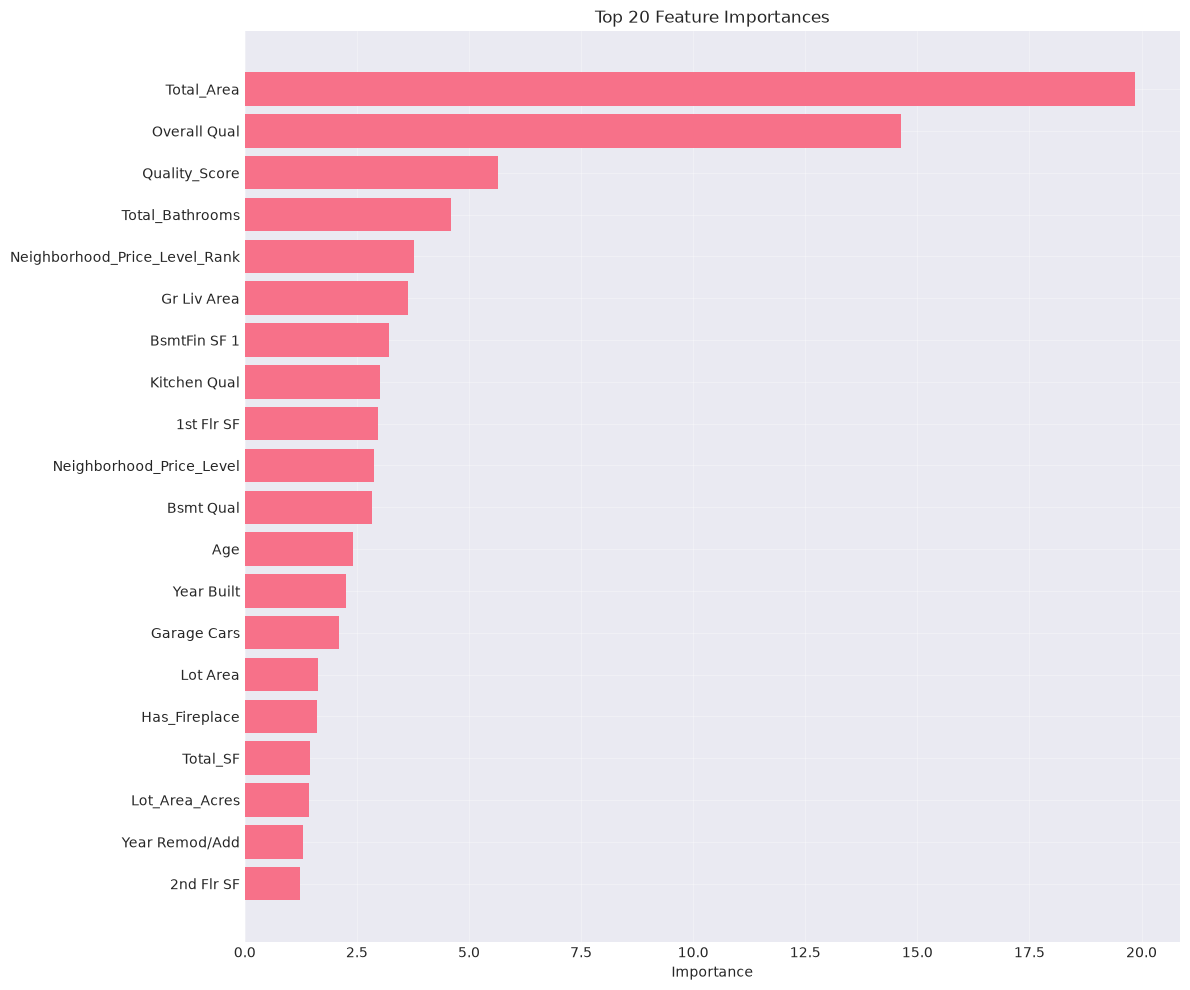

In [14]:
# Plot feature importance
fig, ax = plt.subplots(figsize=(12, 10))

top_features = importance_df.head(20)
ax.barh(top_features['Feature'], top_features['Importance'])
ax.set_xlabel('Importance')
ax.set_title('Top 20 Feature Importances')
ax.invert_yaxis()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. SHAP Analysis

In [15]:
try:
    import shap
    
    # For tree-based models
    if hasattr(model, 'feature_importances_'):
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_test[:100])
        
        # Summary plot
        plt.figure(figsize=(12, 8))
        shap.summary_plot(shap_values, X_test[:100], show=False)
        plt.tight_layout()
        plt.savefig('../reports/figures/shap_summary.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        print('SHAP analysis completed and saved')
    else:
        print('SHAP analysis not supported for this model type')
except ImportError:
    print('SHAP not installed. Install with: pip install shap')
except Exception as e:
    print(f'SHAP analysis error: {e}')

SHAP not installed. Install with: pip install shap


## 5. Summary Statistics

In [16]:
# Prediction errors
errors = y_test - y_pred

print('Prediction Error Statistics:')
print('=' * 40)
print(f'Mean Error: ${errors.mean():,.2f}')
print(f'Std Error: ${errors.std():,.2f}')
print(f'Max Error: ${errors.max():,.2f}')
print(f'Min Error: ${errors.min():,.2f}')
print(f'95% Error Range: ±${1.96 * errors.std():,.2f}')

Prediction Error Statistics:
Mean Error: $1,184.78
Std Error: $21,429.51
Max Error: $164,280.26
Min Error: $-159,563.43
95% Error Range: ±$42,001.84
